In [87]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")


In [88]:
# Load mean sea surface temperature dataset
ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")
# ds = xr.open_dataset("../../data/sst.day.mean.ltm.nc", engine="netcdf4") # 365, 720, 1440
# ds = xr.open_dataset("../../data/sst.mnmean.nc", engine="netcdf4")
# ds = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4") # 12,180,360
ds = xr.open_dataset("../../data/sst.wkmean.1990-present.nc", engine="netcdf4") # 1727 but no countries

# xarray's HTML representation
ds_copy = ds.copy(deep=True)

/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_1379/1112961928.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_1379/1112961928.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")


In [89]:
indices = np.argwhere(np.isnan(ds_ref.sst[0].data))

In [90]:
for (idx_y, idx_x) in indices:
    ds.sst[dict(lat=-idx_y, lon=idx_x)] = np.nan

In [133]:
ds['sst']
# min_coords = [5.5 , 55.5] #latitute, longitude
# max_coords = [35.5,  85.5]

min_coords = [20.5, 0.5] #latitute, longitude
max_coords = [50.5, 40.5]

# indian ocean doesn't have a great variability in sst.
# South Pacific; North Atlantic; Mediteranean Sea

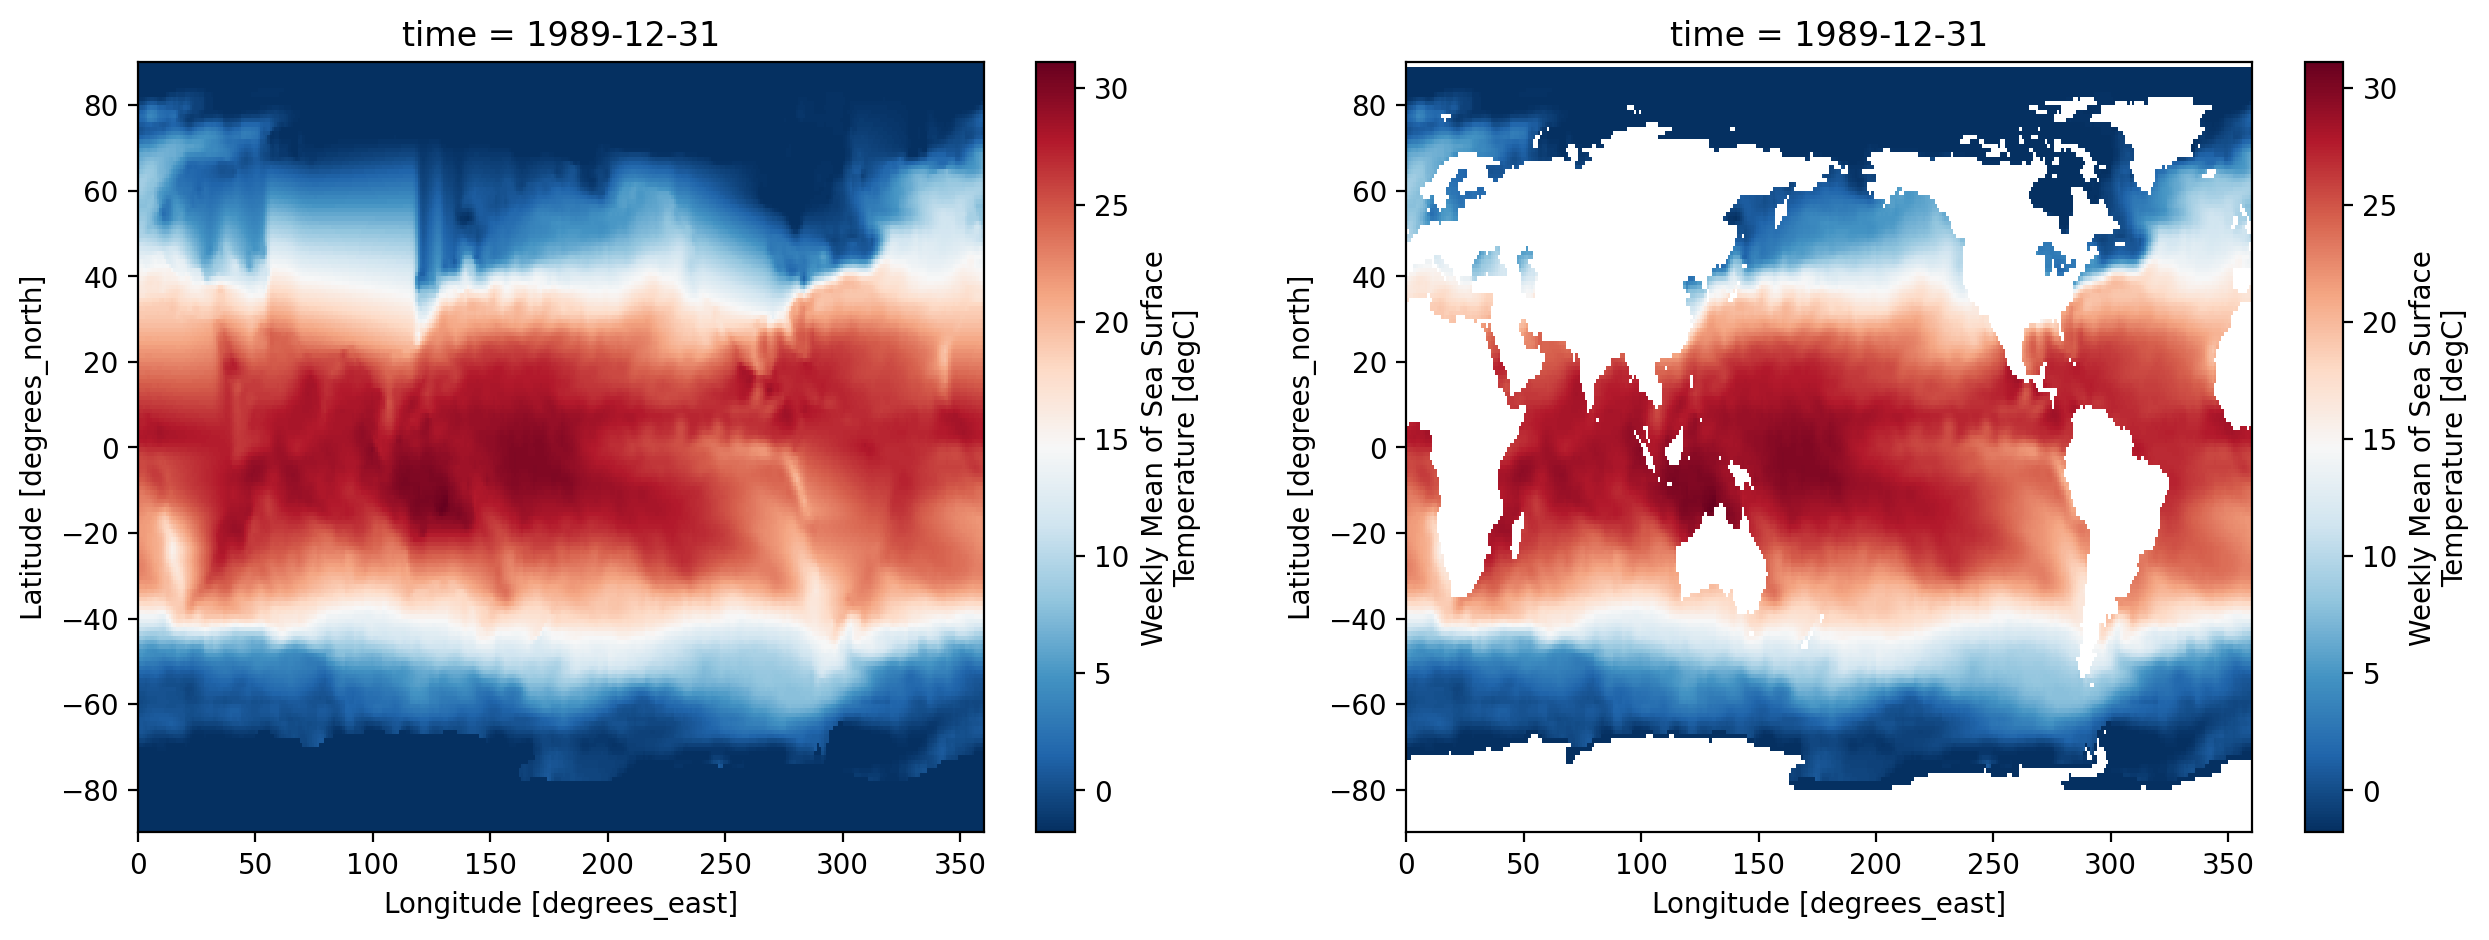

In [134]:
plt.figure(figsize=(15,5))
plt.subplot(121)
ds_copy.sst[0].plot(center=False, cmap='RdBu_r')
plt.subplot(122)
ds.sst[0].plot(center=False, cmap='RdBu_r')

In [135]:
min_temp, max_temp = ds.sst.attrs['actual_range']
print(min_temp, max_temp)
da = ds.sst

-1.8 36.16


In [136]:
print(min_coords, max_coords)

[20.5, 0.5] [50.5, 40.5]


In [137]:
min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])

min_lon_idx = int(np.where(da.lon.data==min_coords[1])[0])
max_lon_idx = int(np.where(da.lon.data==max_coords[1])[0])

print(min_lat_idx, max_lat_idx)
print(min_lon_idx, max_lon_idx)

39 69
0 40


/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_1379/1888061029.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_1379/1888061029.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_1379/1888061029.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operatio

In [138]:
da.data.shape

data_sq = da.data[:, min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]

print("min/max lat/lon values", min_lat_idx, max_lat_idx, min_lon_idx, max_lon_idx)
print("data shape: ", data_sq.shape) # time, lat, lon

min/max lat/lon values 39 69 0 40
data shape:  (1727, 31, 41)


In [139]:
sst_sq = ds.sst[:,min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]

print(sst_sq.shape)

mean_temp = sst_sq.mean(dim="time")
seasonal_mean = sst_sq.groupby("time.season").mean()
seasonal_mean = seasonal_mean.sel(season=["DJF", "MAM", "JJA", "SON"])

std_temp = sst_sq.std(dim="time")
seasonal_ssd = sst_sq.groupby("time.season").std()
seasonal_ssd = seasonal_ssd.sel(season=["DJF", "MAM", "JJA", "SON"])

(1727, 31, 41)


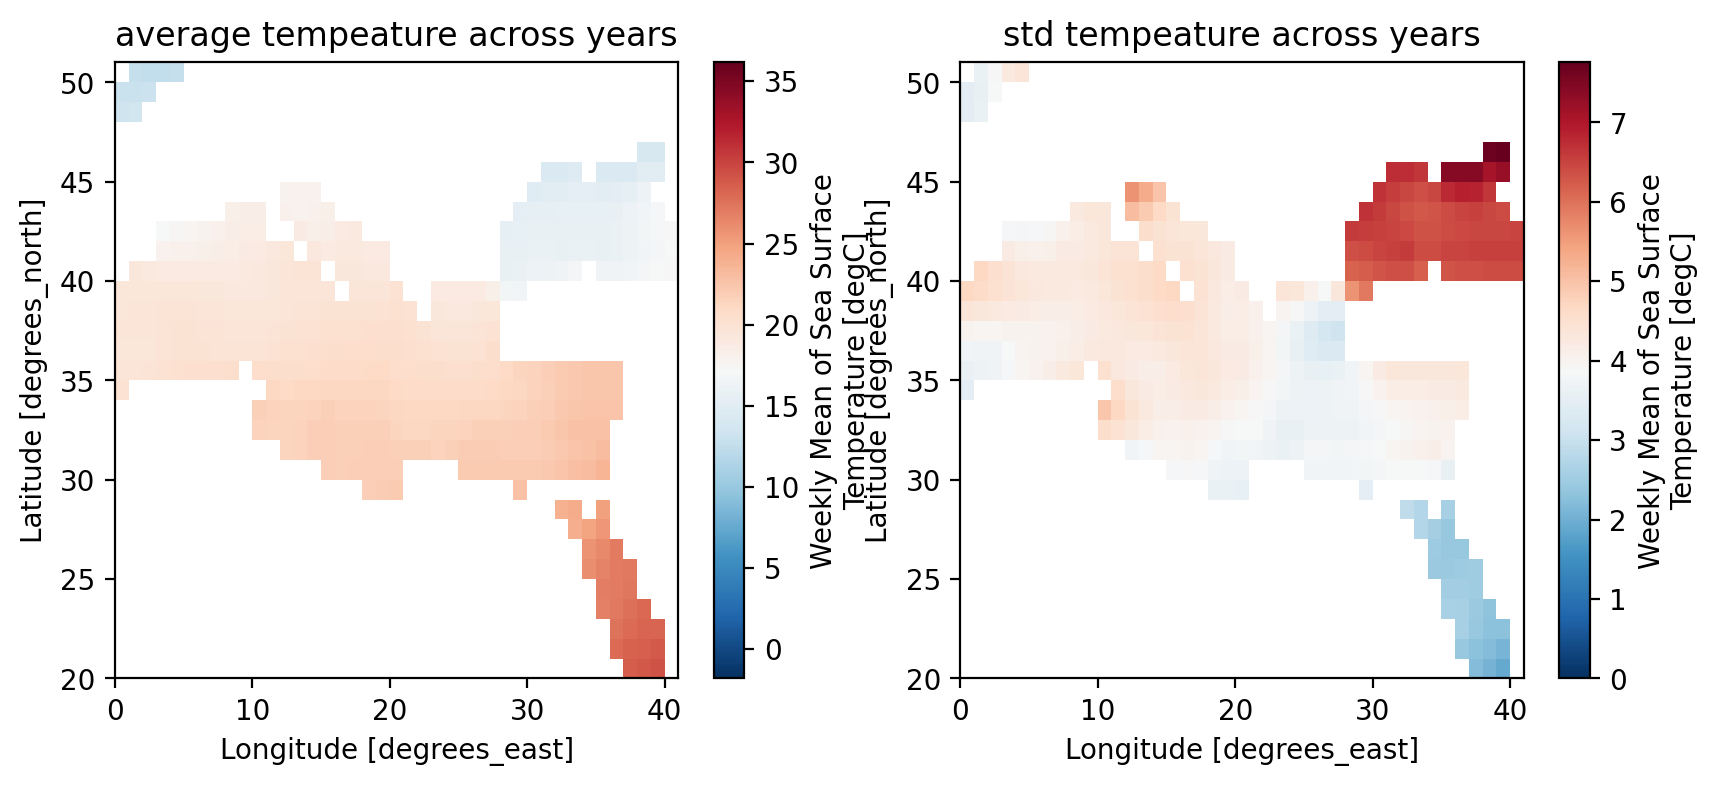

mean tempeature across years grouped by seasons


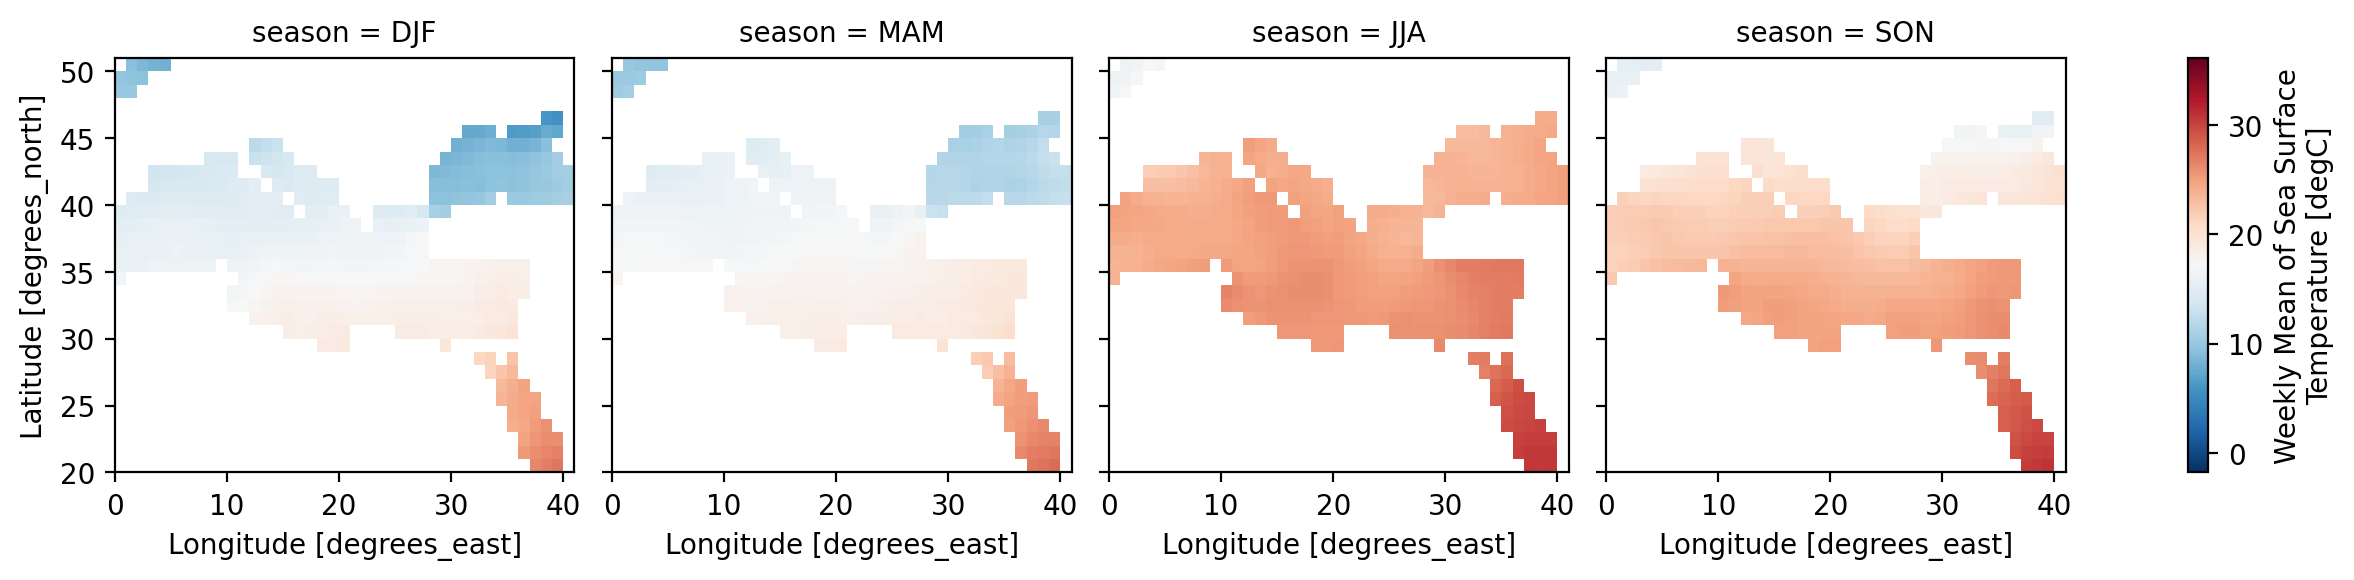

std tempeature across years grouped by seasons


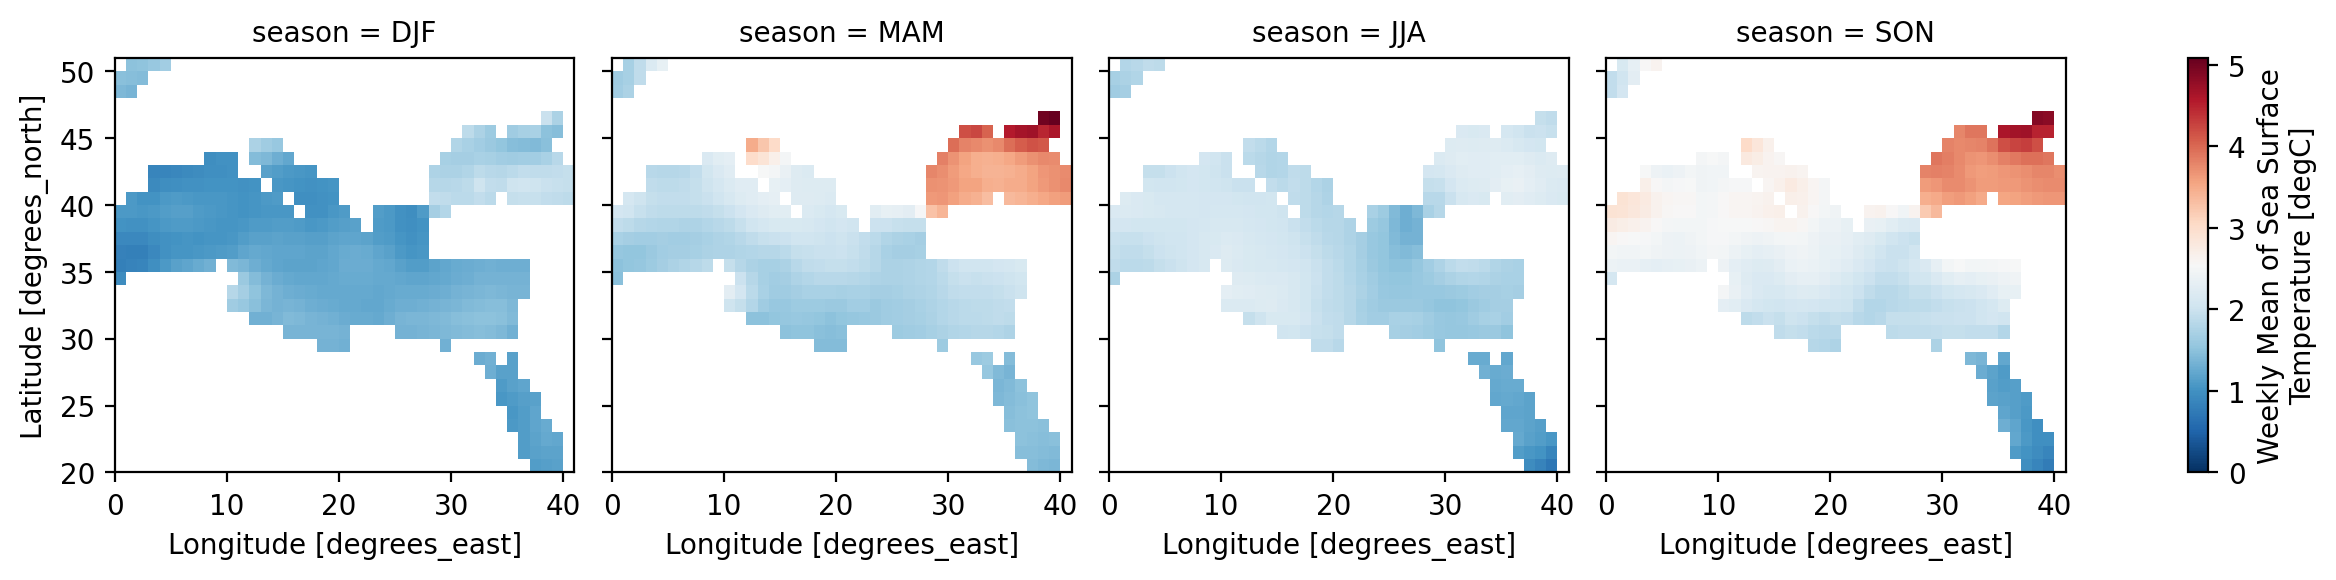

In [140]:
plt.figure(figsize=(10,4))
plt.subplot(121)
mean_temp.plot(cmap='RdBu_r', vmin=min_temp, vmax=max_temp, center=False)
plt.title('average tempeature across years')

plt.subplot(122)
std_temp.plot(cmap='RdBu_r', vmin=0, vmax=std_temp.max())
plt.title('std tempeature across years')
plt.show()

print('mean tempeature across years grouped by seasons')
seasonal_mean.plot(col='season',cmap='RdBu_r', vmin=min_temp, vmax=max_temp, center=False)
plt.show()

print('std tempeature across years grouped by seasons')
seasonal_ssd.plot(col='season',cmap='RdBu_r', vmin=0, vmax=seasonal_ssd.max())
plt.show()


In [141]:
print(sst_sq.shape)

yearly_mean = sst_sq.groupby("time.year").mean()
yearly_std = sst_sq.groupby("time.year").std()

(1727, 31, 41)


In [148]:
sst_sq.shape

(1727, 31, 41)

In [154]:
IDX_lat = 14

val_min = float(min(sst_sq.sel(time='2020').isel(lat=IDX_lat).min(), sst_sq.sel(time='1992').isel(lat=IDX_lat).min()))
val_max = float(max(sst_sq.sel(time='2020').isel(lat=IDX_lat).max(), sst_sq.sel(time='1992').isel(lat=IDX_lat).max()))

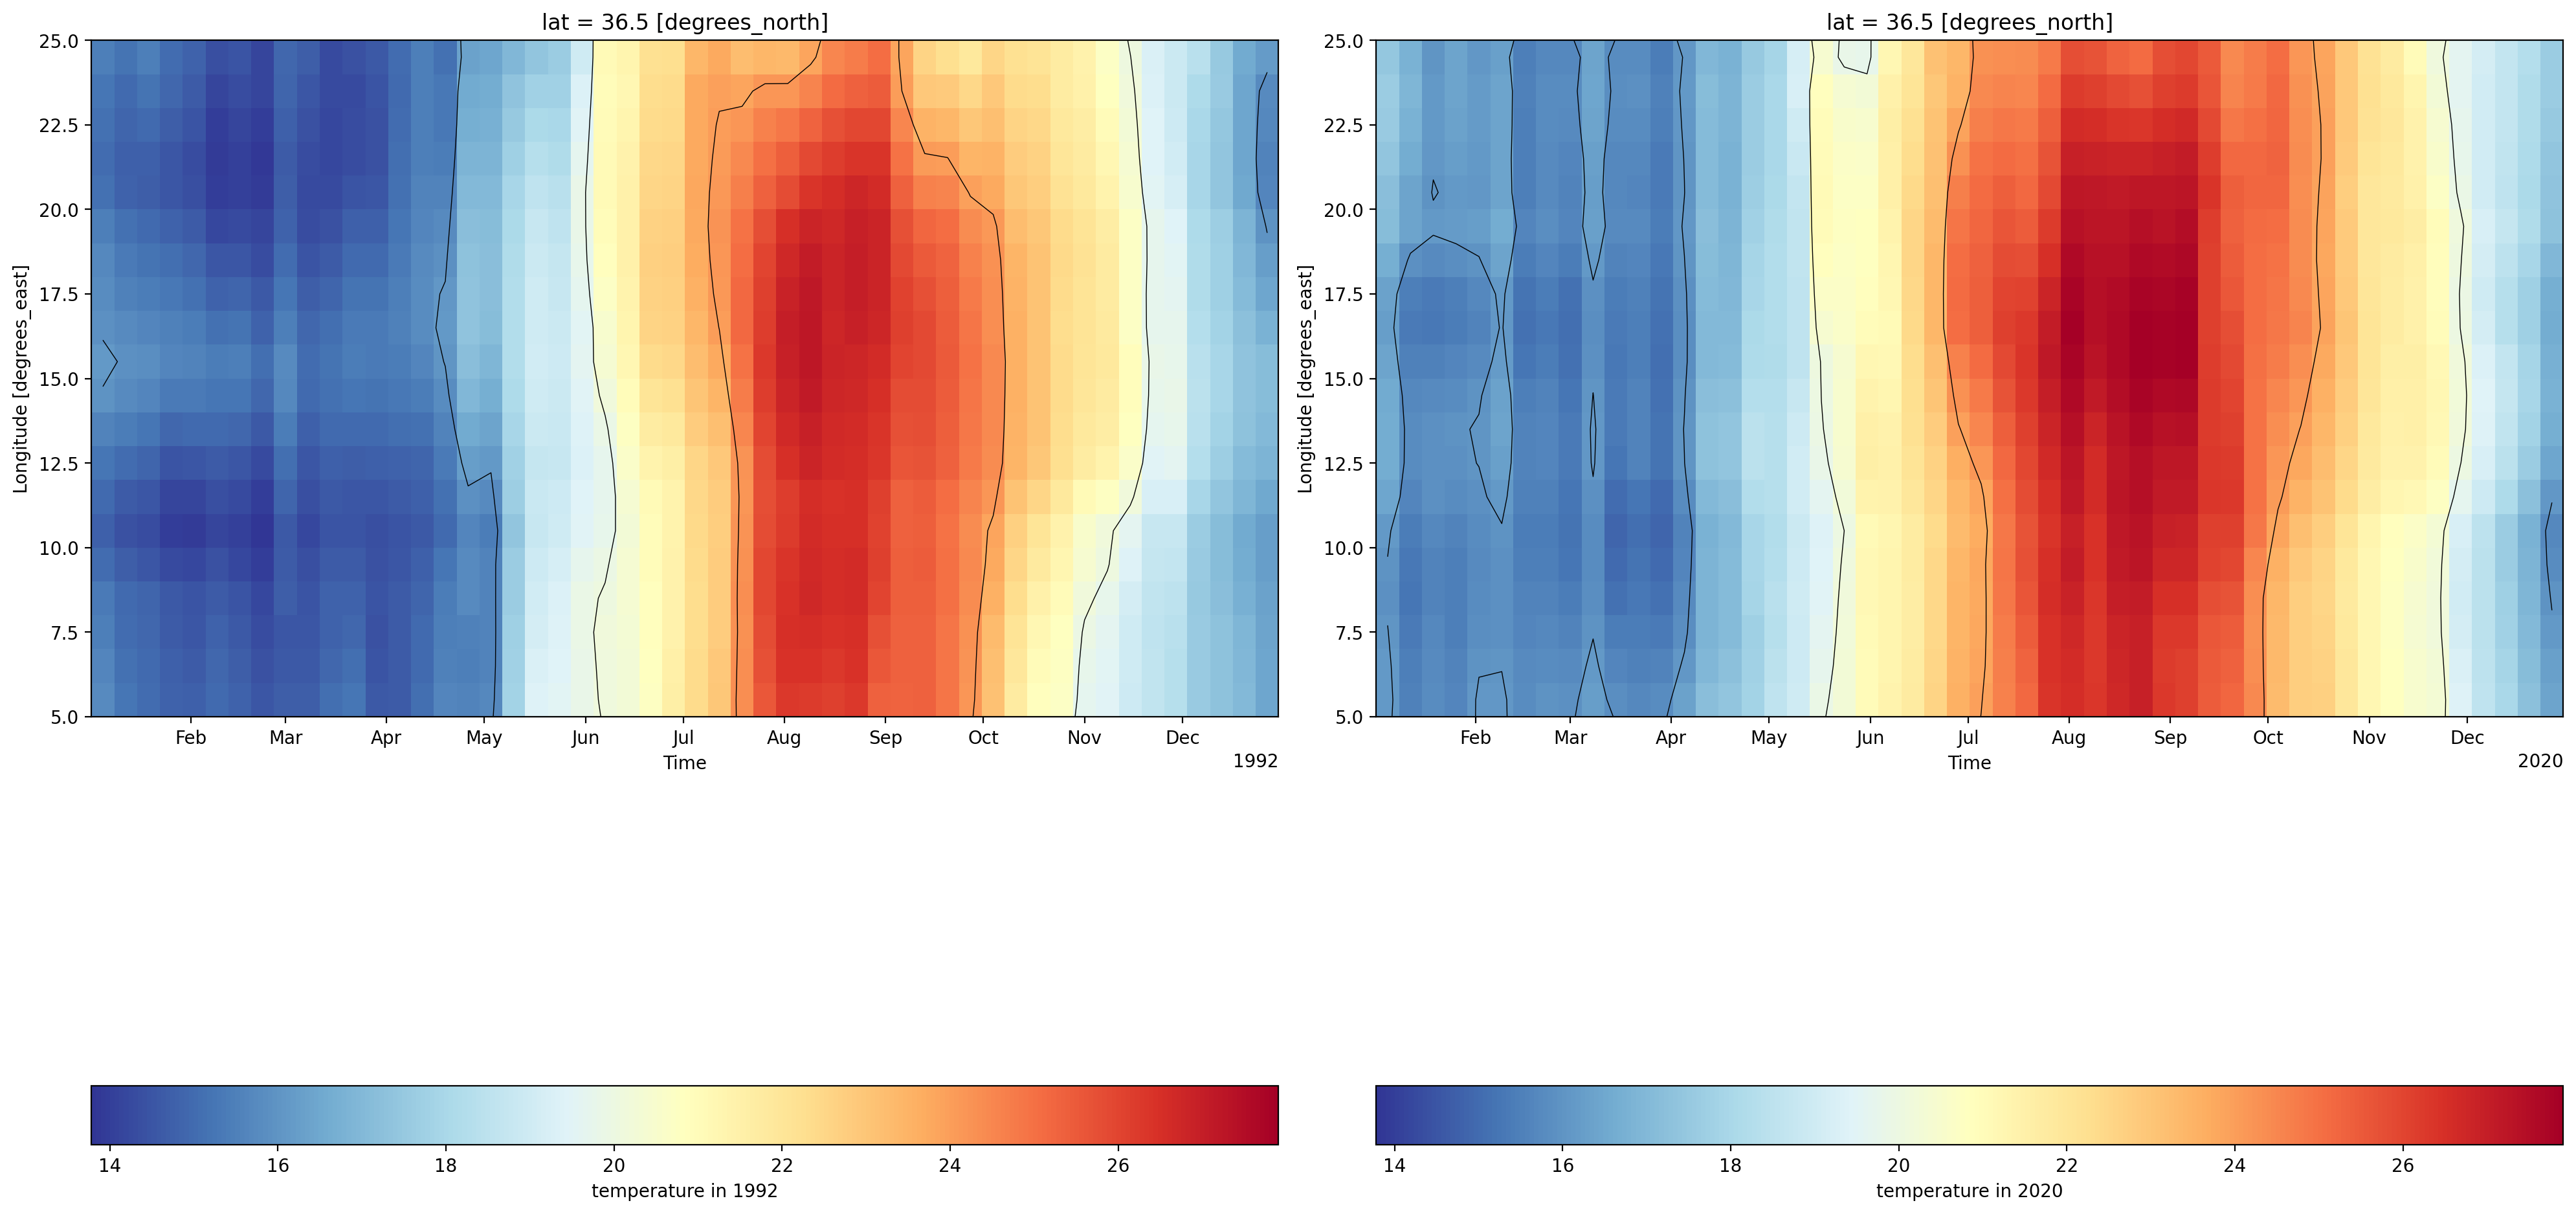

In [155]:
plt.figure(figsize=(20,10))
plt.subplot(121)
sst_sq.sel(time='1992').isel(lat=IDX_lat).plot(
    x="time",  # coordinate to plot on the x-axis of the plot
    cmap='RdYlBu_r',

    cbar_kwargs={ 
        "orientation": "horizontal",
        "label": "temperature in 1992",
        "pad": 0.3,
    },
    ylim=[5,25],
    vmin=val_min,
    vmax=val_max
)

sst_sq.sel(time='1992').isel(lat=IDX_lat).plot.contour(
    x="time",  # coordinate to plot on the x-axis of the plot
    levels=5,  # autoselect 5 levels between max, min
    colors="k",
    linewidths=0.5,
    ylim=[5,25]

)


plt.subplot(122)
sst_sq.sel(time='2020').isel(lat=IDX_lat).plot(
    x="time",  # coordinate to plot on the x-axis of the plot
    cmap='RdYlBu_r',
    cbar_kwargs={ 
        "orientation": "horizontal",
        "label": "temperature in 2020",
        "pad": 0.3,
    },
    ylim=[5,25],
    vmin=val_min,
    vmax=val_max
)
sst_sq.sel(time='2020').isel(lat=IDX_lat).plot.contour(
    x="time",  # coordinate to plot on the x-axis of the plot
    levels=5,  # autoselect 5 levels between max, min
    colors="k",
    linewidths=0.5,
    ylim=[5,25]

)

plt.tight_layout()

In [156]:
print(sst_sq.shape)

(1727, 31, 41)


In [157]:
sst_average_location = sst_sq.mean(dim=['lat','lon'])

In [158]:
sst_year_grouped = sst_average_location.groupby("time.year").mean()
sst_month_grouped = sst_average_location.groupby("time.month")


In [159]:
tos_clim = sst_month_grouped.mean(dim="time")

In [160]:
tos_anom = sst_month_grouped - tos_clim
tos_anom.shape

(1727,)

In [161]:
min_x = int(sst_year_grouped.year.min())
max_x = int(sst_year_grouped.year.max()) +1

In [162]:
q10 = np.quantile(sst_average_location, q=0.10)
q90 = np.quantile(sst_average_location, q=0.90)
sst_mean = int(sst_average_location.mean())

print(q10, sst_mean, q90)

14.825399 20 26.04722


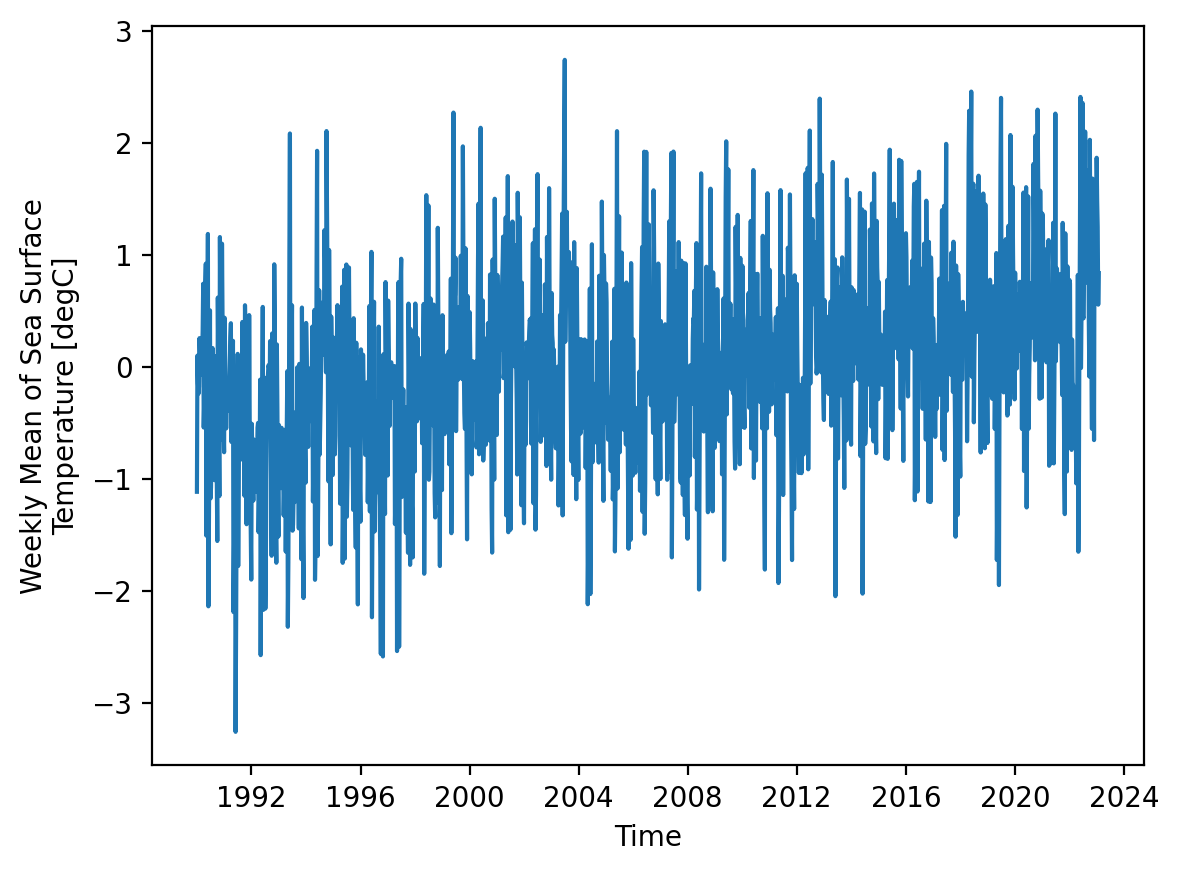

In [163]:
# xaxis_vals = np.arange(min_x, max_x)
plt.figure()
tos_anom.plot()
# plt.axis([min_x, max_x, 26, 30])
# plt.plot(xaxis_vals, np.ones_like(xaxis_vals)*q10)
# plt.plot(xaxis_vals, np.ones_like(xaxis_vals)*q90)
# plt.plot(xaxis_vals, np.ones_like(xaxis_vals)*sst_mean)